# Ch7_Q6 
<h3 >In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

### (a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

In [6]:
from ISLP import load_data
Wage = load_data('Wage')

X = Wage[['age']]
y = Wage['wage']

degrees = range(1, 11)
cv_errors = []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    mse = -np.mean(cross_val_score(model, X, y, cv=10,
                                   scoring="neg_mean_squared_error"))
    cv_errors.append(mse)

best_degree = degrees[np.argmin(cv_errors)]
print("Best degree selected by CV:", best_degree)


Best degree selected by CV: 8


/Users/mabel/opt/anaconda3/envs/tesg_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


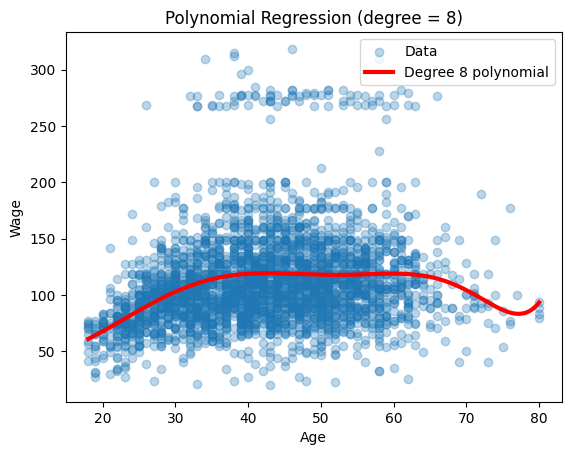

In [7]:
d = best_degree

model = make_pipeline(
    PolynomialFeatures(best_degree, include_bias=False),
    LinearRegression()
)
model.fit(X, y)

age_grid = np.linspace(X.age.min(), X.age.max(), 300).reshape(-1, 1)
wage_pred = model.predict(age_grid)

plt.scatter(X, y, alpha=0.3, label="Data")
plt.plot(age_grid, wage_pred, color="red", linewidth=3, label=f"Degree {d} polynomial")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Polynomial Regression (degree = {d})")
plt.legend()
plt.show()

### (b) Fit a step function to predict wage using age, and perform crossvalidation to choose the optimal number of cuts. Make a plot of the fit obtained.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def cv_step_function(K):
    Wage['age_cut'] = pd.cut(Wage['age'], K)
    ct = ColumnTransformer(
        [('onehot', OneHotEncoder(drop='first'), ['age_cut'])],
        remainder='drop'
    )

    model = make_pipeline(ct, LinearRegression())

    mse = -np.mean(cross_val_score(
        model, Wage[['age_cut']], y,
        scoring='neg_mean_squared_error', cv=10
    ))

    return mse


Ks = range(2, 11)
cv_errors = []

for K in Ks:
    mse = cv_step_function(K)
    cv_errors.append(mse)

best_K = Ks[np.argmin(cv_errors)]
print("Best number of cuts selected by CV:", best_K)

Best number of cuts selected by CV: 8


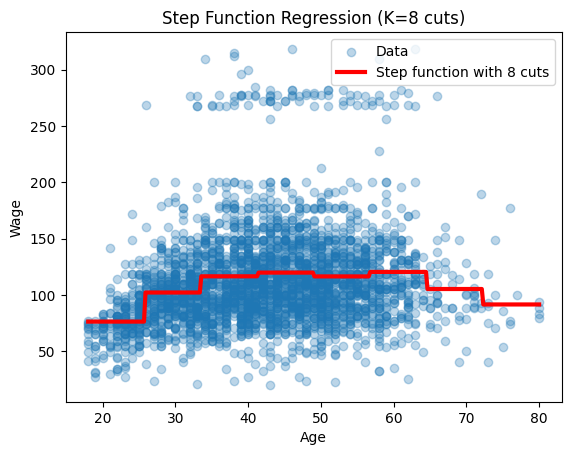

In [9]:
K = best_K
Wage['age_cut'] = pd.cut(Wage['age'], K)

ct = ColumnTransformer(
    [('onehot', OneHotEncoder(drop='first'), ['age_cut'])],
    remainder='drop'
)
model = make_pipeline(ct, LinearRegression())
model.fit(Wage[['age_cut']], y)

age_grid = np.linspace(Wage.age.min(), Wage.age.max(), 300)
age_grid_cut = pd.cut(age_grid, K)

pred_df = pd.DataFrame({'age_cut': age_grid_cut})
wage_pred = model.predict(pred_df)

plt.scatter(Wage['age'], Wage['wage'], alpha=0.3, label="Data")
plt.plot(age_grid, wage_pred, color="red", linewidth=3,
         label=f"Step function with {K} cuts")

plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Step Function Regression (K={K} cuts)")
plt.legend()
plt.show()


# Ch8_Q4
<h3>This question relates to the plots in Figure 8.14.

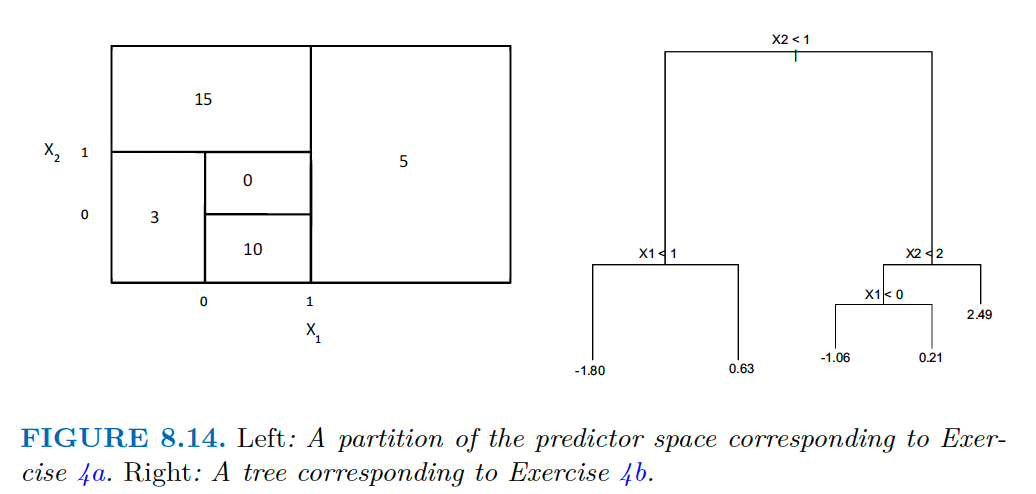

### (a) Sketch the tree corresponding to the partition of the predictor space illustrated in the left-hand panel of Figure 8.14. The numbers inside the boxes indicate the mean of Y within each region.

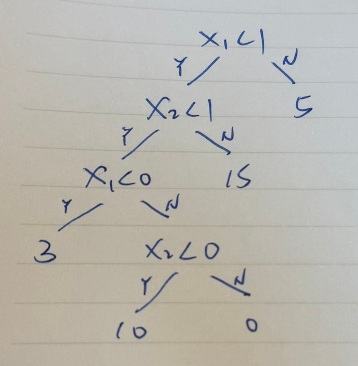

### (b) Create a diagram similar to the left-hand panel of Figure 8.14, using the tree illustrated in the right-hand panel of the same figure. You should divide up the predictor space into the correct regions, and indicate the mean for each region.

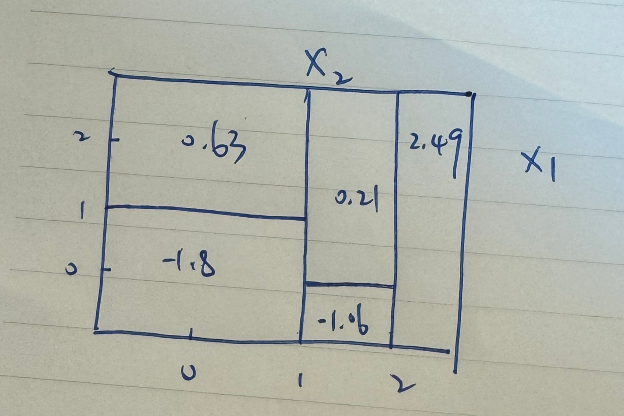

# Ch8_Q8
<h3>
In the lab, a classification tree was applied to the Carseats data set after
converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

### (a) Split the data set into a training set and a test set.

In [10]:
from sklearn.model_selection import train_test_split

Carseats = load_data('Carseats')
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [11]:
Carseats['ShelveLoc'] = Carseats['ShelveLoc'].map({'Bad': -1, 'Good': 1, 'Medium': 0})
Carseats['Urban'] = Carseats['Urban'].map({'No': 0, 'Yes': 1})
Carseats['US'] = Carseats['US'].map({'No': 0, 'Yes': 1})

In [12]:
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,-1,42,17,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1
2,10.06,113,35,10,269,80,0,59,12,1,1
3,7.40,117,100,4,466,97,0,55,14,1,1
4,4.15,141,64,3,340,128,-1,38,13,1,0
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,1,33,14,1,1
396,6.14,139,23,3,37,120,0,55,11,0,1
397,7.41,162,26,12,368,159,0,40,18,1,1
398,5.94,100,79,7,284,95,-1,50,12,1,1


In [13]:
train_df, test_df = train_test_split(Carseats, test_size=0.5, random_state=42)

### (b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
import matplotlib.pyplot as plt

X_train = train_df.drop(columns=["Sales"])
y_train = train_df["Sales"]

X_test  = test_df.drop(columns=["Sales"])
y_test  = test_df["Sales"]

In [15]:
reg_tree = DecisionTreeRegressor(random_state=1, max_depth=4)
reg_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=1)

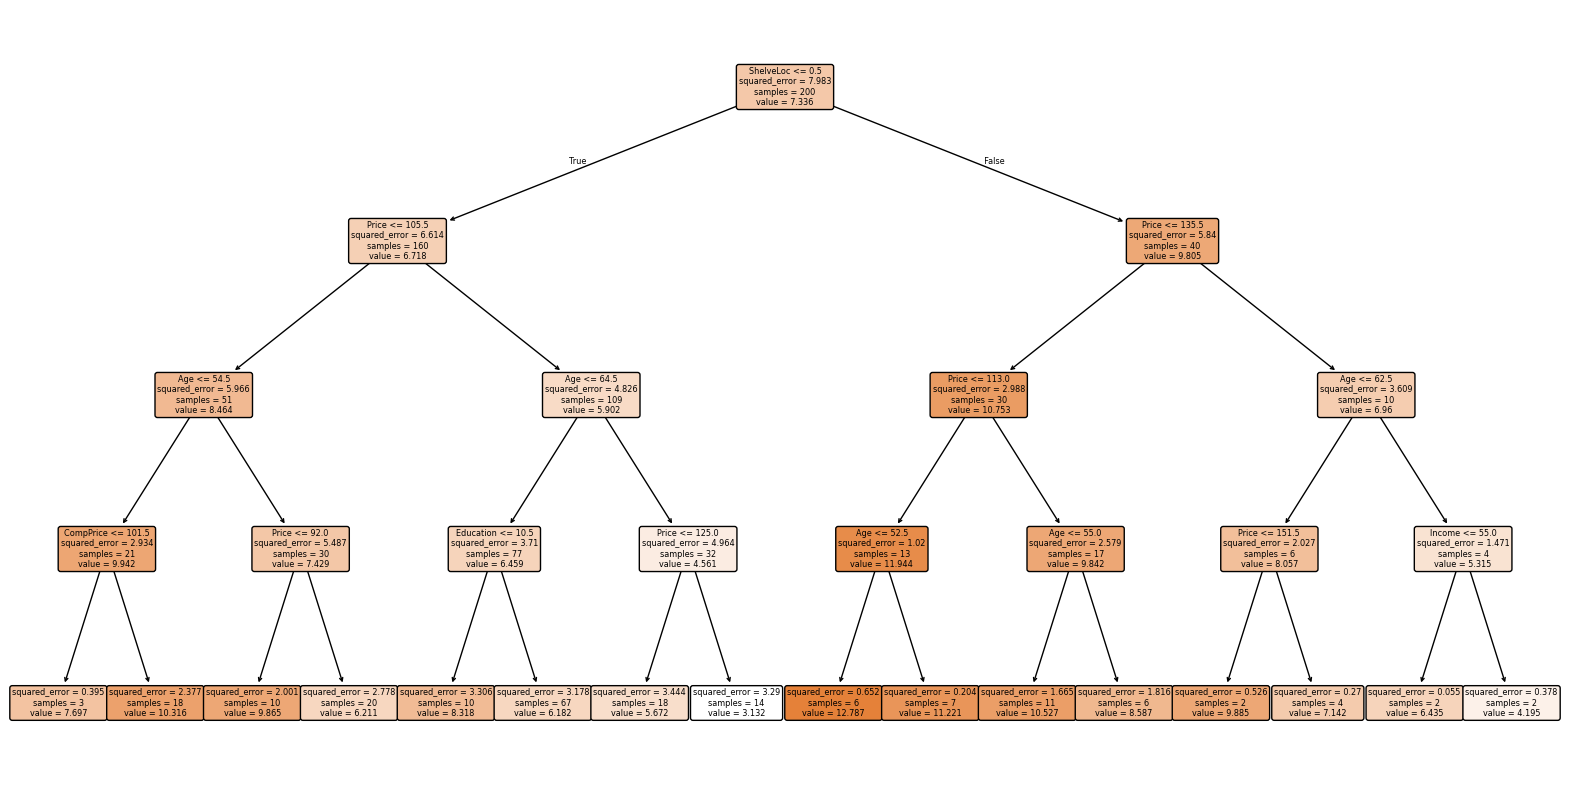

In [16]:
plt.figure(figsize=(20,10))
tree.plot_tree(reg_tree,
               feature_names=X_train.columns,
               filled=True,
               rounded=True)
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error

y_pred = reg_tree.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_mse

5.693949451031239

The most important predictors include Price, ShelveLoc, Age, Education.
The first cut point is ShelveLoc which is the most important predictor of Sales. Second and third cut point are price, next cut point is age. they are also important to sales.


### (c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [18]:
path = reg_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [19]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = []

for alpha in ccp_alphas:
    tree_cv = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha)
    scores = -cross_val_score(
        tree_cv, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=10
    )
    cv_scores.append(scores.mean())

best_alpha = ccp_alphas[np.argmin(cv_scores)]
best_alpha

0.2539365089285811

In [20]:
pruned_tree = DecisionTreeRegressor(random_state=1, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.2539365089285811, random_state=1)

In [21]:
from sklearn.metrics import mean_squared_error

y_pred_full = reg_tree.predict(X_test)
mse_full = mean_squared_error(y_test, y_pred_full)
mse_full

5.693949451031239

In [22]:
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)
mse_pruned

5.281147994902612

Using cost–complexity pruning, we computed a sequence of trees with increasing levels of regularization and performed 10-fold cross-validation to choose the optimal value of α. The cross-validation curve showed that a moderate level of pruning minimized the estimated test MSE. We then refit the tree using the selected α and evaluated both models on the test set. Since the pruned tree has a lower test MSE, pruning improves predictive performance and reduces overfitting.

### (d) Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

p = X_train.shape[1]
bagging_model = RandomForestRegressor(
    n_estimators=500,
    max_features=p,
    bootstrap=True,
    random_state=1
)

bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)
mse_bag

2.807735021020012

In [24]:
import numpy as np

importances = bagging_model.feature_importances_
feature_importance = sorted(
    list(zip(X_train.columns, importances)),
    key=lambda x: x[1],
    reverse=True
)

feature_importance

[('Price', 0.3369117543319512),
 ('ShelveLoc', 0.1976448306532505),
 ('Age', 0.16355573856322264),
 ('CompPrice', 0.09056803005923061),
 ('Advertising', 0.07318267745420731),
 ('Income', 0.0473039826990423),
 ('Population', 0.04168593191208735),
 ('Education', 0.03701377741764128),
 ('Urban', 0.007381294578636216),
 ('US', 0.004751982330730652)]

Price is the most important predictor of Sales, followed by ShelveLoc, Age. This result is consistent with (b)

### (e) Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

p = X_train.shape[1]

m_values = [1, int(np.sqrt(p)), p//2, p] 
results = {}

for m in m_values:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        random_state=1
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results[m] = (rf, mse)

results

{1: (RandomForestRegressor(max_features=1, n_estimators=500, random_state=1),
  4.391974458904011),
 3: (RandomForestRegressor(max_features=3, n_estimators=500, random_state=1),
  3.2551246647380134),
 5: (RandomForestRegressor(max_features=5, n_estimators=500, random_state=1),
  2.907297957204015),
 10: (RandomForestRegressor(max_features=10, n_estimators=500, random_state=1),
  2.807735021020012)}

In [26]:
best_m = min(results, key=lambda m: results[m][1])
best_m, results[best_m][1]

(10, 2.807735021020012)

In [27]:
rf_best = results[best_m][0]
importances = rf_best.feature_importances_

sorted_importances = sorted(
    list(zip(X_train.columns, importances)),
    key=lambda x: x[1],
    reverse=True
)
sorted_importances

[('Price', 0.3369117543319512),
 ('ShelveLoc', 0.1976448306532505),
 ('Age', 0.16355573856322264),
 ('CompPrice', 0.09056803005923061),
 ('Advertising', 0.07318267745420731),
 ('Income', 0.0473039826990423),
 ('Population', 0.04168593191208735),
 ('Education', 0.03701377741764128),
 ('Urban', 0.007381294578636216),
 ('US', 0.004751982330730652)]

We fit random forests to data, and the most important predictors in the random forest are Price, ShelveLoc, Age. These results are consistent with above step.

When m=p (bagging), the error is good but not the best When m is small, the trees are lower variance

Smaller m values produced lower test MSE, Larger m values made the forest behave like bagging, increasing the test error

### (f) Now analyze the data using BART, and report your results.

In [28]:
from ISLP.bart import BART

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

bart = BART(random_state=0, burnin=50, ndraw=200)

bart.fit(X_train.values, y_train.values)

y_pred_bart = bart.predict(X_test.values)

mse_bart = mean_squared_error(y_test, y_pred_bart)
mse_bart

1.414858543691912

In [37]:
vip = bart.variable_inclusion_.mean(0)
var_importance = pd.Series(vip, index=X_train.columns)
var_importance.sort_values(ascending=False)

Price          35.266667
ShelveLoc      30.866667
Age            30.400000
Advertising    29.933333
US             29.866667
Urban          29.400000
CompPrice      28.933333
Population     28.266667
Income         28.200000
Education      28.133333
dtype: float64

Price is the most important predictor, ShelveLoc is the second most important, Age is the third most important predictor.